# Station Location Map
Plot hydrometric station locations on a Natural Earth background using Cartopy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles

In [2]:
csv_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Flowdata\daily_20260522T1321_canada.csv"

df = pd.read_csv(csv_path, skiprows=1)
df.columns = df.columns.str.strip()
df['ID'] = df['ID'].str.strip()

# Keep one row per station
stations = df.drop_duplicates('ID')[['ID', 'Latitude', 'Longitude']].reset_index(drop=True)

# Canadian stations — longitude should be negative (West); negate if stored as positive
if (stations['Longitude'] > 0).all():
    stations['Longitude'] = -stations['Longitude']

print(stations)

        ID  Latitude  Longitude
0  05QE008     50.30     -93.15
1  05QE012     50.40     -93.58
2  05QE009     50.21     -94.27


d:\Users\abolmaal\softwaters\climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Users\abolmaal\softwaters\climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Users\abolmaal\softwaters\climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Users\abolmaal\softwaters\climate\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Users\abolma

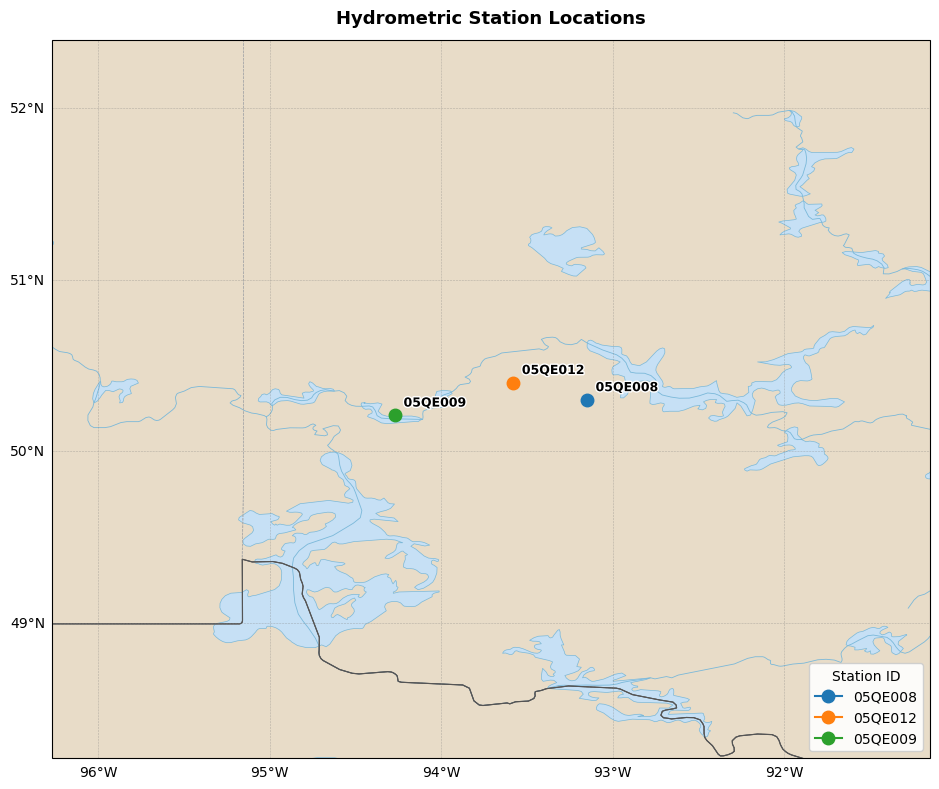

Map saved to station_map.png


In [3]:
pad = 2.0  # degrees of padding around stations
lon_min = stations['Longitude'].min() - pad
lon_max = stations['Longitude'].max() + pad
lat_min = stations['Latitude'].min()  - pad
lat_max = stations['Latitude'].max()  + pad

proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': proj})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# --- Natural Earth features ---
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land',         '10m', facecolor='#e8dcc8', edgecolor='none'))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'ocean',        '10m', facecolor='#c6e0f5', edgecolor='none'))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'lakes',        '10m', facecolor='#c6e0f5', edgecolor='#7ab8d9', linewidth=0.5))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m', facecolor='none', edgecolor='#7ab8d9', linewidth=0.6))
ax.add_feature(cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces', '10m', facecolor='none', edgecolor='#aaaaaa', linewidth=0.5, linestyle='--'))
ax.add_feature(cfeature.NaturalEarthFeature('cultural', 'admin_0_countries', '10m', facecolor='none', edgecolor='#555555', linewidth=0.8))

# --- Gridlines ---
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

# --- Plot stations ---
colors = plt.cm.tab10.colors
for i, row in stations.iterrows():
    ax.plot(row['Longitude'], row['Latitude'],
            marker='o', markersize=9, color=colors[i],
            transform=proj, zorder=5, label=row['ID'])
    ax.text(row['Longitude'] + 0.05, row['Latitude'] + 0.05,
            row['ID'], fontsize=9, fontweight='bold',
            transform=proj, zorder=6,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

ax.legend(title='Station ID', loc='lower right', framealpha=0.9)
ax.set_title('Hydrometric Station Locations', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('station_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved to station_map.png")